# Assignment 1 - Data cleaning & Numerical prediction

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

import torch
import torch.nn as nn 
from torch.utils.data import DataLoader, TensorDataset


from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, f1_score
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler


In [ ]:
USE_BRITS = False
RANDOM_STATE = 16

id_col = "id"
time_col = "time"

target_vars = ["mood"]
interp_cols = ["circumplex.arousal", "circumplex.valence"]

mean_vars = ["mood", "circumplex.arousal", "circumplex.valence", "activity"]
sum_vars = [
    "screen", "call", "sms",
    "appCat.builtin", "appCat.communication", "appCat.entertainment",
    "appCat.finance", "appCat.game", "appCat.office", "appCat.other",
    "appCat.social", "appCat.travel", "appCat.unknown",
    "appCat.utilities", "appCat.weather"
]

# import data 
raw_df = pd.read_csv("dataset_mood_smartphone.csv", low_memory=False)
raw_df[time_col] = pd.to_datetime(raw_df[time_col])

## Data Cleaning

In [ ]:
# helper functions

# predefined intervals 
fixed_bounds = {
    'mood':                  (1,10),
    'circumplex.arousal':    (-2,2),
    'circumplex.valence':    (-2,2),
    'activity':              (0,1),
    'call':                  (1,1), 
    'sms':                   (1,1),
    'screen':                (0, None),
    'appCat.builtin':        (0, None),
    'appCat.communication':  (0, None),
    'appCat.entertainment':  (0, None),
    'appCat.finance':        (0, None),
    'appCat.game':           (0, None),
    'appCat.office':         (0, None),
    'appCat.other':          (0, None),
    'appCat.social':         (0, None),
    'appCat.travel':         (0, None),
    'appCat.unknown':        (0, None),
    'appCat.utilities':      (0, None),
    'appCat.weather':        (0, None),
}
dur_vars = ['screen'] + [v for v in fixed_bounds if v.startswith('appCat')]



def detect_fixed_range_violations(df, fixed_bounds):
    incorrect_records = []

    for var, (low, high) in fixed_bounds.items():
        subset = df[df["variable"] == var]
        if high is None:
            mask = subset["value"] < low
        else:
            mask = (subset["value"] < low) | (subset["value"] > high)

        mark = subset[mask].copy()
        if len(mark) > 0:
            mark["reason"] = "fixed_range_violation"
            mark["original_index"] = mark.index
            incorrect_records.append(mark)

    if len(incorrect_records) == 0:
        return pd.DataFrame(columns=list(df.columns) + ["reason", "original_index"])

    return pd.concat(incorrect_records, ignore_index=True)


def detect_duration_interval_violations(df, duration_vars):
    violation_records = []

    for sid, g_sub in df[df["variable"].isin(duration_vars)].groupby("id", sort=False):
        for var, g in g_sub.groupby("variable", sort=False):
            g = g.sort_values("time").copy()
            g["time_gap_sec"] = g["time"].diff().dt.total_seconds()
            mask = g["time_gap_sec"].notna() & (g["value"] > g["time_gap_sec"])

            mark = g[mask].copy()
            if len(mark) > 0:
                mark["reason"] = "temporal_feasibility_violation"
                mark["original_index"] = mark.index
                violation_records.append(mark)

    if len(violation_records) == 0:
        return pd.DataFrame(columns=list(df.columns) + ["time_gap_sec", "reason", "original_index"])

    return pd.concat(violation_records, ignore_index=True)

In [ ]:
incorrect_df = detect_fixed_range_violations(raw_df, fixed_bounds)
interval_violation_df = detect_duration_interval_violations(raw_df, dur_vars)

incorrect_idx = set(incorrect_df["original_index"])
interval_idx = set(interval_violation_df["original_index"])
remove_idx = incorrect_idx.union(interval_idx)

clean_df = raw_df[~raw_df.index.isin(remove_idx)].copy()

print("Raw rows:", len(raw_df))
print("Fixed-range violations:", len(incorrect_df))
print("Temporal feasibility violations:", len(interval_violation_df))
print("Unique removed:", len(remove_idx))
print("Clean rows:", len(clean_df))

Raw rows: 376912
Fixed-range violations: 4
Temporal feasibility violations: 45976
Unique removed: 45980
Clean rows: 330932


In [ ]:
incorrect_by_var = (
    incorrect_df.groupby("variable").size().rename("fixed_range_violations")
)

interval_by_var = (
    interval_violation_df.groupby("variable").size().rename("temporal_feasibility_violations")
)

cleaning_by_var = pd.concat([incorrect_by_var, interval_by_var], axis=1).fillna(0).astype(int)
cleaning_by_var = cleaning_by_var.sort_values(
    by=["fixed_range_violations", "temporal_feasibility_violations"],
    ascending=False
)

cleaning_by_var

,fixed_range_violations,temporal_feasibility_violations
variable,,
appCat.builtin,3,11591
appCat.entertainment,1,2762
appCat.communication,0,13764
screen,0,12820
appCat.social,0,3275
appCat.office,0,365
appCat.travel,0,350
appCat.finance,0,305
appCat.other,0,301


## Imputation

In [ ]:
clean_df = clean_df.copy()
clean_df[time_col] = pd.to_datetime(clean_df[time_col])

clean_wide_df = (
    clean_df
    .pivot_table(index=[id_col, time_col], columns="variable", values="value", aggfunc="mean")
    .reset_index()
    .sort_values([id_col, time_col])
    .copy()
)

In [ ]:
# define target and feature sets
interp_long = clean_df[clean_df["variable"].isin(interp_cols)].copy()
feature_long = clean_df[~clean_df["variable"].isin(interp_cols)].copy()

interp_wide = (
    interp_long
    .pivot_table(index=["id", "time"], columns="variable", values="value", aggfunc="mean")
    .reset_index()
    .sort_values(["id", "time"])
    .copy()
)

In [ ]:
subjects = clean_wide_df[id_col].drop_duplicates().tolist()

train_ids, temp_ids = train_test_split(subjects, test_size=0.30, random_state=RANDOM_STATE)
val_ids, test_ids = train_test_split(temp_ids, test_size=0.50, random_state=RANDOM_STATE)

train_wide = clean_wide_df[clean_wide_df[id_col].isin(train_ids)].copy()
val_wide   = clean_wide_df[clean_wide_df[id_col].isin(val_ids)].copy()
test_wide  = clean_wide_df[clean_wide_df[id_col].isin(test_ids)].copy()

train_wide["split"] = "train"
val_wide["split"] = "val"
test_wide["split"] = "test"

print(len(train_ids), len(val_ids), len(test_ids))
print(train_wide.shape, val_wide.shape, test_wide.shape)

18 4 5
(237315, 22) (38515, 22) (37415, 22)


In [ ]:
agg_rule_map = {
    "activity": "mean",
    "screen": "sum",
    "call": "sum",
    "sms": "sum",
    
    "appCat.builtin": "sum",
    "appCat.communication": "sum",
    "appCat.entertainment": "sum",
    "appCat.finance": "sum",
    "appCat.game": "sum",
    "appCat.office": "sum",
    "appCat.other": "sum",
    "appCat.social": "sum",
    "appCat.travel": "sum",
    "appCat.unknown": "sum",
    "appCat.utilities": "sum",
    "appCat.weather": "sum",
}

def align_features_to_target_times_window_rules(
    feature_long,
    target_wide,
    agg_rule_map,
    id_col="id",
    time_col="time",
    window="24h",
    default_rule="mean"
):
    feature_long = feature_long.copy()
    target_wide = target_wide.copy()

    feature_long[time_col] = pd.to_datetime(feature_long[time_col])
    target_wide[time_col] = pd.to_datetime(target_wide[time_col])

    feature_vars = sorted(feature_long["variable"].dropna().unique())
    out = []

    for sid, target_g in target_wide.groupby(id_col, sort=False):
        target_g = target_g.sort_values(time_col).copy()
        feat_g = feature_long[feature_long[id_col] == sid].sort_values(time_col).copy()

        rows = []

        for _, row in target_g.iterrows():
            t = row[time_col]
            start = t - pd.Timedelta(window)

            sub = feat_g[(feat_g[time_col] > start) & (feat_g[time_col] <= t)]

            merged = row.to_dict()

            if sub.empty:
                for v in feature_vars:
                    merged[v] = np.nan
            else:
                for v in feature_vars:
                    sub_v = sub.loc[sub["variable"] == v, "value"]

                    if sub_v.empty:
                        merged[v] = np.nan
                    else:
                        rule = agg_rule_map.get(v, default_rule)

                        if rule == "mean":
                            merged[v] = sub_v.mean()
                        elif rule == "sum":
                            merged[v] = sub_v.sum()
                        elif rule == "max":
                            merged[v] = sub_v.max()
                        elif rule == "last":
                            merged[v] = sub_v.iloc[-1]
                        else:
                            raise ValueError(f"Unknown aggregation rule '{rule}' for variable '{v}'")

            rows.append(merged)

        out.append(pd.DataFrame(rows))

    return pd.concat(out, ignore_index=True)

In [ ]:
df_aligned = align_features_to_target_times_window_rules(
    feature_long=feature_long,
    target_wide=interp_wide,
    agg_rule_map=agg_rule_map,
    window="24h"
)

feature_vars = [c for c in df_aligned.columns if c not in ["id", "time"] + target_vars]

for col in feature_vars:
    df_aligned[f"{col}_observed_24h"] = df_aligned[col].notna().astype(int)

# add cyclical features 
df_aligned["hour"] = df_aligned["time"].dt.hour
df_aligned["dayofweek"] = df_aligned["time"].dt.dayofweek

df_aligned["Hour_Sin"] = np.sin(2 * np.pi * df_aligned["hour"] / 24)
df_aligned["Hour_Cos"] = np.cos(2 * np.pi * df_aligned["hour"] / 24)
df_aligned["Day_Sin"] = np.sin(2 * np.pi * df_aligned["dayofweek"] / 7)
df_aligned["Day_Cos"] = np.cos(2 * np.pi * df_aligned["dayofweek"] / 7)

#### Approach 1: linear interpolation

In [ ]:
def interpolate_selected_columns_wide(df_wide, interp_cols, id_col="id", time_col="time"):
    out = []

    for sid, g in df_wide.groupby(id_col, sort=False):
        g = g.sort_values(time_col).copy()
        g[time_col] = pd.to_datetime(g[time_col])
        g = g.set_index(time_col)

        for col in interp_cols:
            if col not in g.columns:
                continue
            g[f"{col}_was_observed_originally"] = g[col].notna().astype(int)
            g[col] = g[col].interpolate(method="time", limit_direction="both")
            g[col] = g[col].ffill().bfill()

        g = g.reset_index()
        out.append(g)

    return pd.concat(out, ignore_index=True)

def plug_in_only_missing(original_df, imputed_df, cols, id_col="id", time_col="time"):
    original = original_df.copy()
    imputed = imputed_df.copy()

    original[time_col] = pd.to_datetime(original[time_col])
    imputed[time_col] = pd.to_datetime(imputed[time_col])

    imp_small = imputed[[id_col, time_col] + cols].copy()
    imp_small = imp_small.rename(columns={col: f"{col}_imp" for col in cols})

    merged = original.merge(imp_small, on=[id_col, time_col], how="left")

    for col in cols:
        merged[f"{col}_was_missing_originally"] = merged[col].isna().astype(int)
        miss_mask = merged[col].isna() & merged[f"{col}_imp"].notna()
        merged.loc[miss_mask, col] = merged.loc[miss_mask, f"{col}_imp"]

    merged = merged.drop(columns=[f"{col}_imp" for col in cols])
    return merged


In [ ]:
train_imp = interpolate_selected_columns_wide(train_wide, interp_cols)
val_imp   = interpolate_selected_columns_wide(val_wide, interp_cols)
test_imp  = interpolate_selected_columns_wide(test_wide, interp_cols)

train_final = plug_in_only_missing(train_wide, train_imp, interp_cols, id_col, time_col)
val_final   = plug_in_only_missing(val_wide, val_imp, interp_cols, id_col, time_col)
test_final  = plug_in_only_missing(test_wide, test_imp, interp_cols, id_col, time_col)

wide_final = pd.concat([train_final, val_final, test_final], ignore_index=True)
wide_final = wide_final.sort_values([id_col, time_col]).reset_index(drop=True)

print(wide_final.shape)

(313245, 24)


#### Approach 2:  BRITS imputation

In [ ]:
exclude_cols = {
    id_col, time_col, 
    'hour', 'dayofweek', 'Hour_Sin', 'Hour_Cos', 'Day_Sin', 'Day_Cos'
}

exclude_cols.update([c for c in train_wide.columns if c.endswith('_was_observed')])
exclude_cols.update([c for c in train_wide.columns if c.endswith('_observed_24h')])

value_cols = [
    c for c in train_wide.columns
    if c not in exclude_cols and pd.api.types.is_any_real_numeric_dtype(train_wide[c])
]

print("Number of BRITS variables:", len(value_cols))
print(value_cols[:20])

Number of BRITS variables: 19
['activity', 'appCat.builtin', 'appCat.communication', 'appCat.entertainment', 'appCat.finance', 'appCat.game', 'appCat.office', 'appCat.other', 'appCat.social', 'appCat.travel', 'appCat.unknown', 'appCat.utilities', 'appCat.weather', 'call', 'circumplex.arousal', 'circumplex.valence', 'mood', 'screen', 'sms']


In [ ]:
def prepare_split(df, id_col = 'id', time_col = 'time'):
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values([id_col, time_col]).reset_index(drop=True)
    return df

# BRITS usually behaves better if variables are on similar scales.
def fit_train_scaler(train_df, value_cols):
    means = train_df[value_cols].mean(skipna=True)
    stds = train_df[value_cols].std(skipna=True).replace(0, 1.0)
    return means, stds

def apply_scaler(df, value_cols, means, stds):
    df = df.copy()
    df[value_cols] = (df[value_cols] - means) / stds
    return df

def df_to_padded_tensor(df, value_cols, id_col="id", time_col="time", max_len=None):
    groups = []
    subject_ids = []
    lengths = []

    grouped = list(df.groupby(id_col, sort=False))

    if max_len is None:
        max_len = max(len(g) for _, g in grouped)

    for sid, g in grouped:
        g = g.sort_values(time_col)
        X = g[value_cols].to_numpy(dtype=float)

        lengths.append(len(g))
        subject_ids.append(sid)

        if len(g) < max_len:
            pad = np.full((max_len - len(g), len(value_cols)), np.nan, dtype=float)
            X = np.vstack([X, pad])
        elif len(g) > max_len:
            raise ValueError(f"Subject {sid} has length {len(g)} > max_len {max_len}")

        groups.append(X)

    X = np.stack(groups, axis=0)
    return X, subject_ids, lengths

def padded_tensor_to_df(X_imp, original_df, subject_ids, lengths, value_cols,
                        id_col="id", time_col="time"):
    out = []

    for i, (sid, L) in enumerate(zip(subject_ids, lengths)):
        g = original_df[original_df[id_col] == sid].sort_values(time_col).copy()
        g[value_cols] = X_imp[i, :L, :]
        out.append(g)

    return pd.concat(out, axis=0, ignore_index=True)

def inverse_scaler(df, value_cols, means, stds):
    df = df.copy()
    df[value_cols] = df[value_cols] * stds + means
    return df


In [ ]:
train_df = prepare_split(train_wide, id_col, time_col)
val_df   = prepare_split(val_wide, id_col, time_col)
test_df  = prepare_split(test_wide, id_col, time_col)

train_means, train_stds = fit_train_scaler(train_df, value_cols)

train_scaled = apply_scaler(train_df, value_cols, train_means, train_stds)
val_scaled   = apply_scaler(val_df, value_cols, train_means, train_stds)
test_scaled  = apply_scaler(test_df, value_cols, train_means, train_stds)

train_grouped = list(train_scaled.groupby(id_col, sort=False))
val_grouped   = list(val_scaled.groupby(id_col, sort=False))
test_grouped  = list(test_scaled.groupby(id_col, sort=False))

global_max_len = max(
    max(len(g) for _, g in train_grouped),
    max(len(g) for _, g in val_grouped),
    max(len(g) for _, g in test_grouped),
)

print("global_max_len =", global_max_len)

global_max_len = 18170


In [ ]:
X_train, train_subject_ids, train_lengths = df_to_padded_tensor(
    train_scaled, value_cols, id_col, time_col, max_len=global_max_len
)

X_val, val_subject_ids, val_lengths = df_to_padded_tensor(
    val_scaled, value_cols, id_col, time_col, max_len=global_max_len
)

X_test, test_subject_ids, test_lengths = df_to_padded_tensor(
    test_scaled, value_cols, id_col, time_col, max_len=global_max_len
)

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

X_train: (18, 18170, 19)
X_val:   (4, 18170, 19)
X_test:  (5, 18170, 19)


In [ ]:
# fit BRITS on training only 
if USE_BRITS:
    from pypots.imputation import BRITS
    
    brits = BRITS(
        n_steps = X_train.shape[1],
        n_features = X_train.shape[2],
        rnn_hidden_size = 64,
        batch_size = 16, 
        epochs = 50,
        patience = 5,
        device = 'cpu',
    )

    brits.fit({"X": X_train})
    
    # impute all splits using the trained model
    X_train_brits = brits.impute({"X": X_train})
    X_val_brits   = brits.impute({"X": X_val})
    X_test_brits  = brits.impute({"X": X_test})
    
    train_brits = padded_tensor_to_df(
        X_train_brits, train_df, train_subject_ids, train_lengths, value_cols
    )

    val_brits = padded_tensor_to_df(
        X_val_brits, val_df, val_subject_ids, val_lengths, value_cols
    )

    test_brits = padded_tensor_to_df(
        X_test_brits, test_df, test_subject_ids, test_lengths, value_cols
    )

    train_brits_df = inverse_scaler(train_brits, value_cols, train_means, train_stds)
    val_brits_df   = inverse_scaler(val_brits, value_cols, train_means, train_stds)
    test_brits_df  = inverse_scaler(test_brits, value_cols, train_means, train_stds)

    train_brits_final = plug_in_only_missing(train_df, train_brits_df, value_cols)
    val_brits_final   = plug_in_only_missing(val_df, val_brits_df, value_cols)
    test_brits_final  = plug_in_only_missing(test_df, test_brits_df, value_cols)

#### Distributional Check

In [ ]:
def distribution_check_two_imputers(original_df, interp_df, brits_df, target_vars,
                                    id_col="id", time_col="time"):
    rows = []

    for var in target_vars:
        observed_mask = original_df[var].notna()
        missing_mask = original_df[var].isna()

        observed_vals = original_df.loc[observed_mask, var].dropna()
        interp_imputed_vals = interp_df.loc[missing_mask, var].dropna()
        brits_imputed_vals = brits_df.loc[missing_mask, var].dropna()

        def summarize(x, label):
            if len(x) == 0:
                return {
                    "variable": var,
                    "group": label,
                    "n": 0,
                    "mean": np.nan,
                    "std": np.nan,
                    "min": np.nan,
                    "q25": np.nan,
                    "median": np.nan,
                    "q75": np.nan,
                    "max": np.nan
                }
            return {
                "variable": var,
                "group": label,
                "n": len(x),
                "mean": x.mean(),
                "std": x.std(),
                "min": x.min(),
                "q25": x.quantile(0.25),
                "median": x.median(),
                "q75": x.quantile(0.75),
                "max": x.max()
            }

        rows.append(summarize(observed_vals, "observed_original"))
        rows.append(summarize(interp_imputed_vals, "imputed_linear"))
        rows.append(summarize(brits_imputed_vals, "imputed_brits"))

    return pd.DataFrame(rows)

In [ ]:
if USE_BRITS:
    dist_train = distribution_check_two_imputers(train_df, train_imp, train_brits, target_vars)
    dist_val   = distribution_check_two_imputers(val_df, val_imp, val_brits, target_vars)
    dist_test  = distribution_check_two_imputers(test_df, test_imp, test_brits, target_vars)

    print(dist_train)
    print(dist_val)
    print(dist_test)

#### Gap-length Sensitivity

In [ ]:
def add_gap_length_info(original_df, target_vars, id_col="id", time_col="time"):
    out = []

    for sid, g in original_df.groupby(id_col, sort=False):
        g = g.sort_values(time_col).copy()

        for var in target_vars:
            miss = g[var].isna().astype(int).values
            gap_len = np.zeros(len(g), dtype=int)

            run = 0
            for i in range(len(g)):
                if miss[i] == 1:
                    run += 1
                else:
                    if run > 0:
                        gap_len[i-run:i] = run
                        run = 0
            if run > 0:
                gap_len[len(g)-run:len(g)] = run

            tmp = g[[id_col, time_col]].copy()
            tmp["variable"] = var
            tmp["is_missing_original"] = miss
            tmp["gap_length"] = gap_len
            out.append(tmp)

    return pd.concat(out, ignore_index=True)

def gap_length_imputation_summary(original_df, interp_df, brits_df, target_vars,
                                  id_col="id", time_col="time"):
    gap_df = add_gap_length_info(original_df, target_vars, id_col, time_col)

    rows = []
    for var in target_vars:
        gap_var = gap_df[gap_df["variable"] == var].copy()

        for gap_len, idx in gap_var.groupby("gap_length").groups.items():
            if gap_len == 0:
                continue

            sub = gap_var.loc[idx]
            merged_lin = sub.merge(
                interp_df[[id_col, time_col, var]],
                on=[id_col, time_col],
                how="left"
            ).rename(columns={var: "linear_value"})

            merged_bri = sub.merge(
                brits_df[[id_col, time_col, var]],
                on=[id_col, time_col],
                how="left"
            ).rename(columns={var: "brits_value"})

            rows.append({
                "variable": var,
                "gap_length": gap_len,
                "n_points": len(sub),
                "linear_mean": merged_lin["linear_value"].mean(),
                "linear_std": merged_lin["linear_value"].std(),
                "brits_mean": merged_bri["brits_value"].mean(),
                "brits_std": merged_bri["brits_value"].std(),
            })

    return pd.DataFrame(rows).sort_values(["variable", "gap_length"])

In [ ]:
if USE_BRITS:
    gap_train = gap_length_imputation_summary(train_df, train_imp, train_brits, target_vars)
    print(gap_train.head(20))

## Feature Engineering 

In [ ]:
mood_source = (
    clean_df.loc[clean_df["variable"] == "mood", [id_col, time_col, "value"]]
    .copy()
    .rename(columns = {"value":"mood"})
)

mood_source[time_col] = pd.to_datetime(mood_source[time_col])
mood_source = mood_source.groupby([id_col, time_col], as_index = False)["mood"].mean()

In [ ]:
def attach_mood(df):
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col])
    if "mood" not in df.columns:
        df = df.merge(mood_source, on=[id_col, time_col], how='left')
    df.sort_values([id_col, time_col], inplace=True )
    df.reset_index(drop=True, inplace=True)
    return df

train_imp_csv = pd.read_csv("train_imp.csv")
val_imp_csv = pd.read_csv("val_imp.csv")
test_imp_csv = pd.read_csv("test_imp.csv")

train_fe_base = attach_mood(train_imp_csv)
val_fe_base = attach_mood(val_imp_csv)
test_fe_base = attach_mood(test_imp_csv)

FEATURE_COLUMNS = (
    "mood_lag1", "mood_lag2", "activity_lag1",
    "mood_mean_3d", "mood_std_3d", "activity_mean_3d", "screen_mean_3d",
    "social_usage_mean_3d", "entertainment_usage_mean_3d",
    "circumplex.arousal_mean_3d", "circumplex.valence_mean_3d",
    "arousal_x_valence",
    "activity_std_5d", "screen_std_5d",
    "sin_day", "cos_day",
)

def _calendar_past_agg(x, id_col, time_col, y, n_calendar_days, stat):
    """Mean/std over prior rows in the same id with calendar date in the last n_calendar_days before target day."""
    out = pd.Series(np.nan, index=x.index, dtype = float)
    y = y.reindex(x.index)
    for _, grp in x.groupby(id_col, sort = False):
        idx = grp.index
        times = grp[time_col].to_numpy()
        vals = y.loc[idx].to_numpy()
        nloc = len(grp)
        local = np.full(nloc, np.nan)
        for i in range(nloc):
            d_i_ts = pd.Timestamp(times[i]).normalize()
            lo_d = (d_i_ts - pd.Timedelta(days=n_calendar_days)).date()
            hi_d = (d_i_ts - pd.Timedelta(days=1)).date()
            acc = []
            for j in range(i):
                dj = pd.Timestamp(times[j]).normalize().date()
                if lo_d <= dj <= hi_d:
                    acc.append(vals[j])
            if stat == "mean":
                if len(acc) > 0:
                    local[i] = np.nanmean(acc)
            elif stat == "std":
                if len(acc) >= 2:
                    local[i] = np.nanstd(acc, ddof=0)
                elif len(acc) == 1:
                    local[i] = 0.0
        out.loc[idx] = local
    return out

def create_advanced_features(
    df,
    id_col="id",
    time_col="time",
    mood_col="mood",
    arousal_col="circumplex.arousal",
    valence_col="circumplex.valence",
    window_short=3,
    window_long=5,
):

    x = df.copy()
    x[time_col] = pd.to_datetime(x[time_col])
    x = x.sort_values([id_col, time_col]).reset_index(drop=True)
    g = x.groupby(id_col, group_keys=False)
    nan_s = pd.Series(np.nan, index=x.index)

    social_cols = [c for c in ["appCat.social", "appCat.communication"] if c in x.columns]
    entertainment_cols = [c for c in ["appCat.entertainment", "appCat.game"] if c in x.columns]
    social_usage = x[social_cols].sum(axis=1) if social_cols else pd.Series(0.0, index=x.index)
    entertainment_usage = (
        x[entertainment_cols].sum(axis=1) if entertainment_cols else pd.Series(0.0, index=x.index)
    )

    feats = {}

    if mood_col not in x.columns:
        raise KeyError("Need column 'mood'.")
    m = x[mood_col]
    feats["mood_lag1"] = g[mood_col].shift(1)
    feats["mood_lag2"] = g[mood_col].shift(2)
    feats["mood_mean_3d"] = _calendar_past_agg(x, id_col, time_col, m, window_short, "mean")
    feats["mood_std_3d"] = _calendar_past_agg(x, id_col, time_col, m, window_short, "std")
    cal_day = pd.to_datetime(x[time_col]).dt.normalize()
    mood_day_mean = x.groupby([x[id_col], cal_day], sort=False)[mood_col].transform("mean")
    target_mood = mood_day_mean

    if "activity" not in x.columns:
        raise KeyError("Need column 'activity'.")
    act = x["activity"]
    feats["activity_lag1"] = g["activity"].shift(1)
    feats["activity_mean_3d"] = _calendar_past_agg(x, id_col, time_col, act, window_short, "mean")
    feats["activity_std_5d"] = _calendar_past_agg(x, id_col, time_col, act, window_long, "std")

    if "screen" not in x.columns:
        raise KeyError("Need column 'screen'.")
    scr = x["screen"]
    feats["screen_mean_3d"] = _calendar_past_agg(x, id_col, time_col, scr, window_short, "mean")
    feats["screen_std_5d"] = _calendar_past_agg(x, id_col, time_col, scr, window_long, "std")

    feats["social_usage_mean_3d"] = _calendar_past_agg(
        x, id_col, time_col, social_usage, window_short, "mean"
    )
    feats["entertainment_usage_mean_3d"] = _calendar_past_agg(
        x, id_col, time_col, entertainment_usage, window_short, "mean"
    )

    if arousal_col in x.columns:
        feats["circumplex.arousal_mean_3d"] = _calendar_past_agg(
            x, id_col, time_col, x[arousal_col], window_short, "mean"
        )
    else:
        feats["circumplex.arousal_mean_3d"] = nan_s.copy()
    if valence_col in x.columns:
        feats["circumplex.valence_mean_3d"] = _calendar_past_agg(
            x, id_col, time_col, x[valence_col], window_short, "mean"
        )
    else:
        feats["circumplex.valence_mean_3d"] = nan_s.copy()
    if arousal_col in x.columns and valence_col in x.columns:
        feats["arousal_x_valence"] = x[arousal_col] * x[valence_col]
    else:
        feats["arousal_x_valence"] = nan_s.copy()

    _dow = x[time_col].dt.dayofweek
    feats["sin_day"] = np.sin(2 * np.pi * _dow / 7)
    feats["cos_day"] = np.cos(2 * np.pi * _dow / 7)

    # time: string range from (target date - window_long) through target date
    period_start_vals, period_end_vals = [], []
    for _, h in x.groupby(id_col, sort=False):
        t = h[time_col]
        for i in range(len(h)):
            ts = pd.Timestamp(t.iloc[i])
            end_d = ts.normalize()
            start_d = end_d - pd.Timedelta(days=window_long)
            period_start_vals.append(start_d)
            period_end_vals.append(end_d)
    period_start = pd.Series(period_start_vals, index=x.index)
    period_end = pd.Series(period_end_vals, index=x.index)
    time_period = (
        period_start.dt.strftime("%Y-%m-%d")
        + " to "
        + period_end.dt.strftime("%Y-%m-%d")
    )

    out = pd.DataFrame(feats)
    out[id_col] = x[id_col]
    out[time_col] = time_period
    out["target_mood"] = target_mood

    # From day 6: one row per calendar day
    first_day = x.groupby(id_col)[time_col].transform("min").dt.normalize()
    row_ok = x[time_col].dt.normalize() >= first_day + pd.Timedelta(days=5)
    out = out.loc[row_ok].copy()
    x_ok = x.loc[row_ok].reset_index(drop=True)
    out = out.reset_index(drop=True)
    out["_ts"] = x_ok[time_col].values
    out["_cal"] = pd.to_datetime(x_ok[time_col]).dt.normalize().values
    out = out.sort_values([id_col, "_cal", "_ts"])
    out = out.groupby([id_col, "_cal"], as_index=False).last()
    out = out.drop(columns=["_ts", "_cal"])

    return out[[id_col, time_col, *FEATURE_COLUMNS, "target_mood"]]

# train / val / test
train_fe = create_advanced_features(train_fe_base, id_col=id_col, time_col=time_col)
val_fe   = create_advanced_features(val_fe_base,   id_col=id_col, time_col=time_col)
test_fe  = create_advanced_features(test_fe_base,  id_col=id_col, time_col=time_col)

print("train_fe shape:", train_fe.shape)
print("val_fe shape:  ", val_fe.shape)
print("test_fe shape: ", test_fe.shape)

display(train_fe.head())

def round_numeric(df, decimals=4):
    df = df.copy()
    num_cols = df.select_dtypes(include=[np.number]).columns
    df[num_cols] = df[num_cols].round(decimals)
    return df


train_fe = round_numeric(train_fe)
val_fe = round_numeric(val_fe)
test_fe = round_numeric(test_fe)

train_fe.to_csv("train_feature_engineered.csv", index=False)
val_fe.to_csv("val_feature_engineered.csv", index=False)
test_fe.to_csv("test_feature_engineered.csv", index=False)

/var/folders/z1/7kbjhk_n18x0w1rlzpp72dl40000gn/T/ipykernel_5941/156173248.py:49: RuntimeWarning: Mean of empty slice
  local[i] = np.nanmean(acc)
/opt/anaconda3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/z1/7kbjhk_n18x0w1rlzpp72dl40000gn/T/ipykernel_5941/156173248.py:49: RuntimeWarning: Mean of empty slice
  local[i] = np.nanmean(acc)
/opt/anaconda3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/z1/7kbjhk_n18x0w1rlzpp72dl40000gn/T/ipykernel_5941/156173248.py:49: RuntimeWarning: Mean of empty slice
  local[i] = np.nanmean(acc)
/opt/anaconda3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=d

train_fe shape: (741, 19)
val_fe shape:   (160, 19)
test_fe shape:  (239, 19)


,id,time,mood_lag1,mood_lag2,activity_lag1,mood_mean_3d,mood_std_3d,activity_mean_3d,screen_mean_3d,social_usage_mean_3d,entertainment_usage_mean_3d,circumplex.arousal_mean_3d,circumplex.valence_mean_3d,arousal_x_valence,activity_std_5d,screen_std_5d,sin_day,cos_day,target_mood
0,AS14.02,2014-03-16 to 2014-03-21,8.0,6.0,0.252843,7.428571,0.979379,0.240076,3070.319644,2136.637500,123.494500,0.214286,0.642857,-1.0,0.067374,677.338221,-0.433884,-0.900969,7.50
1,AS14.02,2014-03-17 to 2014-03-22,6.0,6.0,0.503017,7.153846,0.948371,0.255216,3070.458078,1856.002000,110.356462,-0.230769,0.615385,-0.0,0.062000,736.177489,-0.974928,-0.222521,6.50
2,AS14.02,2014-03-18 to 2014-03-23,6.0,6.0,0.250419,7.083333,0.862007,0.347340,3678.847334,2003.427583,267.110833,-0.750000,0.333333,1.0,0.112011,806.370439,-0.781831,0.623490,6.25
3,AS14.02,2014-03-19 to 2014-03-24,5.0,6.0,0.168080,6.750000,0.924211,0.331301,3722.101334,1888.559583,303.938083,-0.916667,0.083333,-1.0,0.103264,810.212486,0.000000,1.000000,6.40
4,AS14.02,2014-03-20 to 2014-03-25,8.0,8.0,0.219082,6.384615,0.835598,0.309426,3031.689770,1534.137154,392.688385,-0.538462,-0.230769,-0.0,0.107311,1006.821366,0.781831,0.623490,7.75


## Classification


In [ ]:
train_data = pd.concat(
    [pd.read_csv("train_feature_engineered.csv"), pd.read_csv("val_feature_engineered.csv")],
    ignore_index=True,
)
test_data = pd.read_csv("test_feature_engineered.csv")

X = train_data.drop(columns=["target_mood", "id", "time"])
y = np.clip(np.rint(train_data["target_mood"]).astype(int), 1, 10)

clf = HistGradientBoostingClassifier(
    learning_rate=0.04,
    max_depth=8,
    max_iter=700,
)

clf.fit(X, y)

# Predict for each subject separately 
test_subject_predictions = {}
for subject_id, subject_df in test_data.groupby("id",sort=True):
    X_subject = subject_df.drop(columns=["id", "time", "target_mood"])
    subject_pred = clf.predict(X_subject)
    test_subject_predictions[subject_id] = subject_pred
    print(f"{subject_id}: n={len(subject_pred)}, sample={subject_pred[:10]}")

X_test = test_data.drop(columns=["id", "time", "target_mood"])
pred_classes = clf.predict(X_test)

y_test = np.clip(np.rint(test_data["target_mood"]).astype(int), 1, 10)
f1_macro = f1_score(y_test, pred_classes, average="macro")
f1_weighted = f1_score(y_test, pred_classes, average="weighted")
print("\nTest F1-macro:", f1_macro)
print("Test F1-weighted:", f1_weighted)

per_subject_eval = pd.DataFrame(
    {"id": test_data["id"], "y_true": y_test, "y_pred": pred_classes}
).groupby("id",sort=True)

f1_per_test_subject = (
    per_subject_eval
    .apply(lambda d: f1_score(d["y_true"], d["y_pred"], average="macro"))
    .rename("f1_macro")
    .sort_values(ascending=False)
)
acc_per_test_subject = (
    per_subject_eval
    .apply(lambda d: accuracy_score(d["y_true"], d["y_pred"]))
    .rename("accuracy")
    .sort_values(ascending=False)
)

print("\nTest F1-macro per subject:")
print(f1_per_test_subject)
print("\nTest accuracy per subject:")
print(acc_per_test_subject)
print("\nMean subject accuracy:", acc_per_test_subject.mean())

AS14.12: n=40, sample=[6 7 7 6 7 7 6 6 6 6]
AS14.15: n=50, sample=[7 7 7 7 7 7 7 7 7 7]
AS14.16: n=48, sample=[7 6 6 7 6 7 7 7 6 6]
AS14.17: n=51, sample=[7 7 6 6 7 8 6 8 7 7]
AS14.24: n=50, sample=[7 8 8 7 8 7 6 8 7 7]

Test F1-macro: 0.5643275970675351
Test F1-weighted: 0.8112651406782008

Test F1-macro per subject:
id
AS14.15    0.734848
AS14.17    0.722100
AS14.24    0.591966
AS14.12    0.516762
AS14.16    0.408333
Name: f1_macro, dtype: float64

Test accuracy per subject:
id
AS14.15    0.920000
AS14.17    0.843137
AS14.24    0.820000
AS14.16    0.770833
AS14.12    0.750000
Name: accuracy, dtype: float64

Mean subject accuracy: 0.8207941176470588


## Numerical Prediction

### Data preparation

In [ ]:
daily_source = wide_final.copy()
daily_source[time_col] = pd.to_datetime(daily_source[time_col])
daily_source["date"] = daily_source[time_col].dt.floor("D")

indicator_cols = [c for c in daily_source.columns if c.endswith("_was_missing_originally")]

def sum_preserve_nan(x):
    return x.sum(min_count=1)

agg_map = {}
for col in daily_source.columns:
    if col in [id_col, time_col, "date", "split"]:
        continue
    elif col in mean_vars:
        agg_map[col] = "mean"
    elif col in sum_vars:
        agg_map[col] = sum_preserve_nan
    elif col in indicator_cols:
        agg_map[col] = "max"
    elif pd.api.types.is_numeric_dtype(daily_source[col]):
        agg_map[col] = "mean"


# aggregation to daily level
daily_wide = (
    daily_source
    .groupby([id_col, 'date', 'split'], as_index = False)
    .agg(agg_map)
    .sort_values([id_col, 'date'])
    .reset_index(drop = True)
)

In [ ]:
# define next-day mood as forecasting target 
daily_wide = daily_wide.sort_values([id_col, 'date']).copy()

daily_wide['target_next_obs_mood'] = (
    daily_wide.groupby(id_col)['mood'].shift(-1)
)

# drop rows without next-observed mood
daily_model_df = daily_wide.dropna(subset=["target_next_obs_mood"]).copy()

train_daily = daily_model_df[daily_model_df["split"] == "train"].copy()
val_daily   = daily_model_df[daily_model_df["split"] == "val"].copy()
test_daily  = daily_model_df[daily_model_df["split"] == "test"].copy()

print(train_daily.shape, val_daily.shape, test_daily.shape)

(814, 25) (189, 25) (265, 25)


In [ ]:
# choose predictor columns 
predictor_cols = [
    c for c in daily_wide.columns
    if c not in [id_col, 'date', 'split', 'target_next_obs_mood']
]

train_missing = train_daily[predictor_cols].isna().mean()

predictor_cols = train_missing[train_missing <= 0.50].index.tolist()
print("Number of predictors kept:", len(predictor_cols))
print(predictor_cols)

Number of predictors kept: 13
['activity', 'appCat.builtin', 'appCat.communication', 'appCat.entertainment', 'appCat.other', 'appCat.social', 'call', 'circumplex.arousal', 'circumplex.valence', 'mood', 'screen', 'circumplex.arousal_was_missing_originally', 'circumplex.valence_was_missing_originally']


### Approach 1: LSTM

In [ ]:
date_col = "date"
target_col = "target_next_obs_mood"

In [ ]:
def fill_daily_predictors_within_subject(df, cols, id_col="id", date_col="date"):
    out = []
    for sid, g in df.groupby(id_col, sort=False):
        g = g.sort_values(date_col).copy()
        g[cols] = g[cols].ffill().bfill()
        out.append(g)
    return pd.concat(out, ignore_index=True)

train_daily_filled = fill_daily_predictors_within_subject(train_daily, predictor_cols)
val_daily_filled   = fill_daily_predictors_within_subject(val_daily, predictor_cols)
test_daily_filled  = fill_daily_predictors_within_subject(test_daily, predictor_cols)

train_means = train_daily_filled[predictor_cols].mean()
train_stds = train_daily_filled[predictor_cols].std().replace(0, 1.0)

for df in [train_daily_filled, val_daily_filled, test_daily_filled]:
    df[predictor_cols] = (df[predictor_cols] - train_means) / train_stds


# Persist daily tables for Classification LSTM (same features/target as Approach 1)
def _export_daily_for_classifier(df, path):
    out = df.copy()
    out["target_class"] = np.clip(
        np.rint(out["target_next_obs_mood"]).astype(int), 1, 10
    )
    out.to_csv(path, index=False)

_export_daily_for_classifier(train_daily_filled, "train_daily_lstm_classifier.csv")
_export_daily_for_classifier(val_daily_filled, "val_daily_lstm_classifier.csv")
_export_daily_for_classifier(test_daily_filled, "test_daily_lstm_classifier.csv")
pd.DataFrame({"predictor": predictor_cols}).to_csv(
    "daily_lstm_classifier_predictors.csv", index=False
)
print(
    "Wrote train_daily_lstm_classifier.csv, val_daily_lstm_classifier.csv, "
    "test_daily_lstm_classifier.csv, daily_lstm_classifier_predictors.csv"
)


In [49]:
# LSTM classifier
PRED = pd.read_csv("daily_lstm_classifier_predictors.csv")["predictor"].tolist()


def _load(path):
    df = pd.read_csv(path)
    df["date"] = pd.to_datetime(df["date"])
    return df


train_df, val_df, test_df = (
    _load("train_daily_lstm_classifier.csv"),
    _load("val_daily_lstm_classifier.csv"),
    _load("test_daily_lstm_classifier.csv"),
)

SEQ_LEN, BATCH, HIDDEN, DROPOUT, EPOCHS, PATIENCE = 7, 32, 32, 0.2, 100, 10


def sequences(df, seq_len):
    X, y, ids = [], [], []
    for sid, g in df.groupby("id", sort=False):
        g = g.sort_values("date")
        xv = g[PRED].to_numpy(dtype=np.float32)
        yv = g["target_class"].to_numpy(dtype=np.int64)
        if len(g) <= seq_len:
            continue
        for i in range(seq_len, len(g)):
            win = xv[i - seq_len : i]
            t = yv[i]
            if np.isnan(win).any() or np.isnan(t):
                continue
            X.append(win)
            y.append(t)
            ids.append(sid)
    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.int64),
        np.asarray(ids),
    )


X_train, y_train_hi, _ = sequences(train_df, SEQ_LEN)
X_val, y_val_hi, _ = sequences(val_df, SEQ_LEN)
X_test, y_test_hi, test_ids = sequences(test_df, SEQ_LEN)

y_train = torch.tensor(y_train_hi - 1, dtype=torch.long)
y_val = torch.tensor(y_val_hi - 1, dtype=torch.long)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train), y_train), batch_size=BATCH, shuffle=False
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val), y_val), batch_size=BATCH, shuffle=False
)


class LSTMClassification(nn.Module):
    def __init__(self, input_dim, n_classes=10, hidden=32, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden, n_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.dropout(out[:, -1, :]))


model = LSTMClassification(len(PRED), hidden=HIDDEN, dropout=DROPOUT).to(device)
crit = nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

best_acc, best_state, bad_epochs = -1.0, None, 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = crit(model(xb), yb)
        loss.backward()
        opt.step()
        train_loss += loss.item() * len(xb)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss, y_true, y_pred = 0.0, [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            val_loss += crit(logits, yb).item() * len(xb)
            y_true.extend((yb.cpu().numpy() + 1).tolist())
            y_pred.extend((logits.argmax(1).cpu().numpy() + 1).tolist())
    val_loss /= len(val_loader.dataset)
    val_acc = accuracy_score(y_true, y_pred)
    print(
        f"Epoch {epoch:03d}/{EPOCHS} train_loss={train_loss:.4f} val_ce={val_loss:.4f} "
        f"val_acc={val_acc:.4f} val_f1_macro={f1_score(y_true, y_pred, average='macro'):.4f}"
    )

    if val_acc > best_acc:
        best_acc, best_state, bad_epochs = val_acc, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
    else:
        bad_epochs += 1
        if bad_epochs >= PATIENCE:
            print(f"Early stopping (val accuracy, patience={PATIENCE}).")
            break

print(f"Best val accuracy: {best_acc:.4f}")

if best_state is not None:
    model.load_state_dict(best_state)
model.to(device)

model.eval()
chunks = []
with torch.no_grad():
    for i in range(0, len(X_test), 256):
        chunks.append(model(torch.from_numpy(X_test[i : i + 256]).to(device)).argmax(1).cpu().numpy() + 1)
y_pred_test = np.concatenate(chunks)

print("LSTM test accuracy:", accuracy_score(y_test_hi, y_pred_test))
print("LSTM test F1-macro:", f1_score(y_test_hi, y_pred_test, average="macro"))
print("LSTM test F1-weighted:", f1_score(y_test_hi, y_pred_test, average="weighted"))

by_sub = pd.DataFrame({"id": test_ids, "y_true": y_test_hi, "y_pred": y_pred_test}).groupby("id", sort=True)
acc_sub = by_sub.apply(lambda d: accuracy_score(d["y_true"], d["y_pred"]))
f1_sub = by_sub.apply(lambda d: f1_score(d["y_true"], d["y_pred"], average="macro"))
print("\nLSTM accuracy per subject:\n", acc_sub.sort_values(ascending=False))
print("Mean subject accuracy:", acc_sub.mean())
print("\nLSTM F1-macro per subject:\n", f1_sub.sort_values(ascending=False))
print("Mean subject F1-macro:", f1_sub.mean())


Epoch 001/100 train_loss=2.3201 val_ce=2.2214 val_acc=0.2671 val_f1_macro=0.0979
Epoch 002/100 train_loss=2.1813 val_ce=2.0458 val_acc=0.5280 val_f1_macro=0.1728
Epoch 003/100 train_loss=1.9503 val_ce=1.6777 val_acc=0.5280 val_f1_macro=0.1728
Epoch 004/100 train_loss=1.5177 val_ce=1.3009 val_acc=0.5280 val_f1_macro=0.1728
Epoch 005/100 train_loss=1.2641 val_ce=1.2167 val_acc=0.5280 val_f1_macro=0.1728
Epoch 006/100 train_loss=1.2120 val_ce=1.1666 val_acc=0.5280 val_f1_macro=0.1728
Epoch 007/100 train_loss=1.1623 val_ce=1.1464 val_acc=0.5280 val_f1_macro=0.1728
Epoch 008/100 train_loss=1.1456 val_ce=1.1277 val_acc=0.5217 val_f1_macro=0.1897
Epoch 009/100 train_loss=1.1370 val_ce=1.1158 val_acc=0.5093 val_f1_macro=0.1866
Epoch 010/100 train_loss=1.1135 val_ce=1.1043 val_acc=0.5342 val_f1_macro=0.2333
Epoch 011/100 train_loss=1.0980 val_ce=1.0944 val_acc=0.5342 val_f1_macro=0.2506
Epoch 012/100 train_loss=1.0903 val_ce=1.0931 val_acc=0.5342 val_f1_macro=0.2609
Epoch 013/100 train_loss=1.0

In [ ]:
def make_lstm_seq(df, predictor_cols, target_col, seq_len=7,
                        id_col="id", date_col="date"):
    X_list = []
    y_list = []
    meta_list = []

    for sid, g in df.groupby(id_col, sort=False):
        g = g.sort_values(date_col).copy()

        X_vals = g[predictor_cols].to_numpy(dtype=float)
        y_vals = g[target_col].to_numpy(dtype=float)
        dates = g[date_col].to_numpy()

        if len(g) <= seq_len:
            continue

        for i in range(seq_len, len(g)):
            X_seq = X_vals[i-seq_len:i]
            y_target = y_vals[i]

            if np.isnan(X_seq).any() or np.isnan(y_target):
                continue

            X_list.append(X_seq)
            y_list.append(y_target)
            meta_list.append((sid, dates[i]))

    X = np.array(X_list, dtype=float)
    y = np.array(y_list, dtype=float)
    meta = pd.DataFrame(meta_list, columns=[id_col, date_col])

    return X, y, meta

In [ ]:
seq_len = 7 
X_train, y_train, meta_train = make_lstm_seq(
    train_daily_filled, predictor_cols, "target_next_obs_mood", seq_len=seq_len
)

X_val, y_val, meta_val = make_lstm_seq(
    val_daily_filled, predictor_cols, "target_next_obs_mood", seq_len=seq_len
)

X_test, y_test, meta_test = make_lstm_seq(
    test_daily_filled, predictor_cols, "target_next_obs_mood", seq_len=seq_len
)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)


X_train: (688, 7, 13) y_train: (688,)
X_val: (161, 7, 13) y_val: (161,)
X_test: (230, 7, 13) y_test: (230,)


In [ ]:
train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=batch_size,
    shuffle = False
)

val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=batch_size,
    shuffle=False
)

In [ ]:
class LSTMRegression(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, dropout_rate = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        out, _ = self.lstm(x)   #(batch_size, seq_len, hidden_dim)
        last = out[:, -1, :]    #last time step
        last = self.dropout(last)
        out = self.fc(last)
        return out 

In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def train_one_lstm_seed(
        seed,
        X_train,
        y_train,
        X_val,
        y_val,
        hidden_units=32,
        dropout_rate=0.2,
        epochs=100,
        batch_size=32,
        patience=10,
):
    set_seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

    train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=batch_size,
    shuffle = False
    )

    val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=batch_size,
    shuffle=False
    )

    model = LSTMRegression(
        input_dim=X_train.shape[2],
        hidden_dim=hidden_units,
        dropout_rate=dropout_rate
    ).to(device)

    criterion = nn.L1Loss()
    optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

    train_losses = []
    val_losses = []

    best_val = float("inf")
    best_state = None
    wait = 0

    for epoch in range(epochs):
        model.train()
        running_train = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()

            running_train += loss.item() * xb.size(0)
        epoch_train_loss = running_train / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        model.eval()
        running_val = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                loss = criterion(pred, yb)
                running_val += loss.item() * xb.size(0)
        
        epoch_val_loss = running_val / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        if epoch_val_loss < best_val:
            best_val = epoch_val_loss
            best_state = model.state_dict()
            wait = 0
        else:
            wait += 1 
            if wait >= patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    
    history = {
        "loss": train_losses,
        "val_loss": val_losses
    }

    return model, history, best_val

def predict_lstm(model, X):
    device = next(model.parameters()).device
    X_t = torch.tensor(X, dtype= torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        pred = model(X_t).cpu().numpy().flatten()
    return pred 

In [ ]:
seeds = [1, 7, 15, 21, 36, 42, 57, 63, 88, 99]

models = []
histories = []
val_maes = []

val_preds = []
test_preds = []

for seed in seeds:
    model, history, best_val_mae = train_one_lstm_seed(
        seed=seed,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        hidden_units=32,
        dropout_rate=0.2,
        epochs=100,
        batch_size=32,
        patience=10
    )

    models.append(model)
    histories.append(history)
    val_maes.append(best_val_mae)

    val_pred = predict_lstm(model, X_val)
    test_pred = predict_lstm(model, X_test)

    val_preds.append(val_pred)
    test_preds.append(test_pred)

    print(f"Seed {seed}: best val MAE = {best_val_mae:.4f}")

Seed 1: best val MAE = 0.4150
Seed 7: best val MAE = 0.4145
Seed 15: best val MAE = 0.4236
Seed 21: best val MAE = 0.4207
Seed 36: best val MAE = 0.4384
Seed 42: best val MAE = 0.4243
Seed 57: best val MAE = 0.4257
Seed 63: best val MAE = 0.4402
Seed 88: best val MAE = 0.4860
Seed 99: best val MAE = 0.4365


In [ ]:
val_preds = np.vstack(val_preds)
test_preds = np.vstack(test_preds)

val_pred_ensemble = val_preds.mean(axis=0)
test_pred_ensemble = test_preds.mean(axis=0)

ensemble_val_mae = mean_absolute_error(y_val, val_pred_ensemble)
ensemble_val_mse = mean_squared_error(y_val, val_pred_ensemble)
ensemble_val_rmse = np.sqrt(ensemble_val_mse)

ensemble_test_mae = mean_absolute_error(y_test, test_pred_ensemble)
ensemble_test_mse = mean_squared_error(y_test, test_pred_ensemble)
ensemble_test_rmse = np.sqrt(ensemble_test_mse)

print("Ensemble val MAE:", ensemble_val_mae)
print("Ensemble val MSE:", ensemble_val_mse)
print("Ensemble val RMSE:", ensemble_val_rmse)

print("Ensemble test MAE:", ensemble_test_mae)
print("Ensemble test MSE:", ensemble_test_mse)
print("Ensemble test RMSE:", ensemble_test_rmse)

Ensemble val MAE: 0.4275603811686578
Ensemble val MSE: 0.33320183320974334
Ensemble val RMSE: 0.5772363755081131
Ensemble test MAE: 0.4503782199085623
Ensemble test MSE: 0.3991670892596467
Ensemble test RMSE: 0.6317967151383795


In [ ]:
# import tensorflow as tf 
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
# from tensorflow.keras.callbacks import EarlyStopping

# design model 
# def set_seed(seed):
#     random.seed(seed)
#     np.random.seed(seed)
#     tf.random.set_seed(seed)

# def build_lstm_model(input_shape, hidden_units=32, dropout_rate=0.2):
#     model = Sequential([
#     Input(shape=input_shape),
#     LSTM(hidden_units),
#     Dropout(dropout_rate),
#     Dense(1)
# ])

#     model.compile(
#     optimizer="adam",
#     loss="mae",
#     metrics=["mse"]
# )
#     return model

# def train_one_lstm_seed(seed, X_train, y_train, X_val, y_val,
#                         hidden_units=32, dropout_rate=0.2,
#                         epochs=100, batch_size=32, patience=10):
#     set_seed(seed)

#     model = build_lstm_model(
#         input_shape=(X_train.shape[1], X_train.shape[2]),
#         hidden_units=hidden_units,
#         dropout_rate=dropout_rate
#     )

#     early_stop = EarlyStopping(
#         monitor="val_loss",
#         patience=patience,
#         restore_best_weights=True
#     )

#     history = model.fit(
#         X_train, y_train,
#         validation_data=(X_val, y_val),
#         epochs=epochs,
#         batch_size=batch_size,
#         verbose=0,
#         shuffle=False,
#         callbacks=[early_stop]
#     )

#     best_val_mae = min(history.history["val_loss"])
#     return model, history, best_val_mae


# seeds = [1, 7, 15, 21, 36, 42, 57, 63, 88, 99]

# models = []
# histories = []
# val_maes = []

# val_preds = []
# test_preds = []

# for seed in seeds:
#     model, history, best_val_mae = train_one_lstm_seed(
#         seed=seed,
#         X_train=X_train,
#         y_train=y_train,
#         X_val=X_val,
#         y_val=y_val,
#         hidden_units=32,
#         dropout_rate=0.2,
#         epochs=100,
#         batch_size=32,
#         patience=10
#     )

#     models.append(model)
#     histories.append(history)
#     val_maes.append(best_val_mae)

#     val_pred = model.predict(X_val, verbose=0).flatten()
#     test_pred = model.predict(X_test, verbose=0).flatten()

#     val_preds.append(val_pred)
#     test_preds.append(test_pred)

#     print(f"Seed {seed}: best val MAE = {best_val_mae:.4f}")

# plt.figure(figsize=(8, 4))
# for seed, history in zip(seeds, histories):
#     plt.plot(history.history["val_loss"], label=f"seed {seed}")
# plt.xlabel("Epoch")
# plt.ylabel("Validation MAE")
# plt.title("Validation curves across seeds")
# plt.legend()
# plt.tight_layout()
# plt.show()

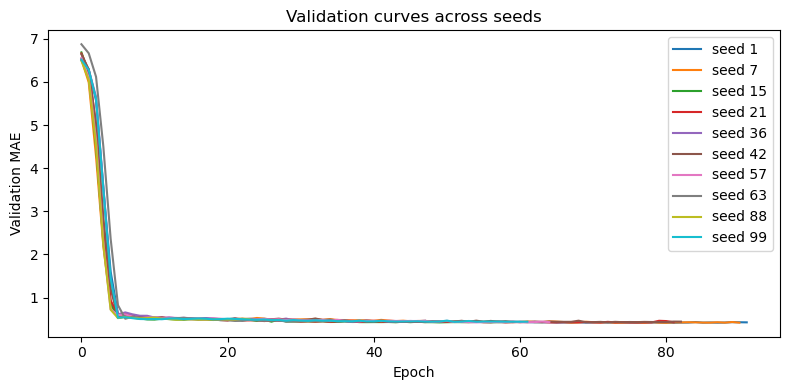

In [ ]:
plt.figure(figsize=(8, 4))
for seed, history in zip(seeds, histories):
    plt.plot(history["val_loss"], label=f"seed {seed}")
plt.xlabel("Epoch")
plt.ylabel("Validation MAE")
plt.title("Validation curves across seeds")
plt.legend()
plt.tight_layout()
plt.show()

### Approach 2: Ridge regression

In [ ]:
# flatten sequence inputs(feature engineered)
train_data = pd.read_csv("train_feature_engineered.csv")
val_data = pd.read_csv("val_feature_engineered.csv")
test_data = pd.read_csv("test_feature_engineered.csv")

drop_cols = ["target_mood", "id", "time"]
drop_cols = [c for c in drop_cols if c in train_data.columns]

X_train = train_data.drop(columns=drop_cols)
X_val   = val_data.drop(columns=drop_cols)
X_test  = test_data.drop(columns=drop_cols)

y_train = train_data["target_mood"].to_numpy()
y_val   = val_data["target_mood"].to_numpy()
y_test  = test_data["target_mood"].to_numpy()

print(X_train.shape, X_val.shape, X_test.shape)
print(X_train.columns.tolist())

(741, 16) (160, 16) (239, 16)
['mood_lag1', 'mood_lag2', 'activity_lag1', 'mood_mean_3d', 'mood_std_3d', 'activity_mean_3d', 'screen_mean_3d', 'social_usage_mean_3d', 'entertainment_usage_mean_3d', 'circumplex.arousal_mean_3d', 'circumplex.valence_mean_3d', 'arousal_x_valence', 'activity_std_5d', 'screen_std_5d', 'sin_day', 'cos_day']


In [ ]:
non_numeric_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
print("Non-numeric columns:", non_numeric_cols)

train_means = X_train.mean()

X_train = X_train.fillna(train_means)
X_val   = X_val.fillna(train_means)
X_test  = X_test.fillna(train_means)

Non-numeric columns: []


In [ ]:
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]

best_alpha = None
best_val_mae = np.inf
best_model = None

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)

    val_pred = model.predict(X_val)
    val_mae = mean_absolute_error(y_val, val_pred)

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_alpha = alpha
        best_model = model

print("Best alpha:", best_alpha)
print("Best validation MAE:", best_val_mae)

Best alpha: 100.0
Best validation MAE: 0.29175940908180636


In [ ]:
val_pred = best_model.predict(X_val)
test_pred = best_model.predict(X_test)

ridge_val_mae = mean_absolute_error(y_val, val_pred)
ridge_val_mse = mean_squared_error(y_val, val_pred)
ridge_val_rmse = np.sqrt(ridge_val_mse)

ridge_test_mae = mean_absolute_error(y_test, test_pred)
ridge_test_mse = mean_squared_error(y_test, test_pred)
ridge_test_rmse = np.sqrt(ridge_test_mse)

print("Ridge val MAE:", ridge_val_mae)
print("Ridge val MSE:", ridge_val_mse)
print("Ridge val RMSE:", ridge_val_rmse)

print("Ridge test MAE:", ridge_test_mae)
print("Ridge test MSE:", ridge_test_mse)
print("Ridge test RMSE:", ridge_test_rmse)

Ridge val MAE: 0.29175940908180636
Ridge val MSE: 0.1780295480330461
Ridge val RMSE: 0.4219354785189865
Ridge test MAE: 0.19644961813626993
Ridge test MSE: 0.07859610490735322
Ridge test RMSE: 0.28034996862377787
